In [ ]:
from pathlib import Path
import time
import cProfile
import pstats
import io
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

MODEL_PATH = PROJECT_ROOT / "models" / "optimized_lightgbm.pkl"
X_TEST_PATH = PROJECT_ROOT / "data" / "X_test.pkl"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [13]:
model = joblib.load(MODEL_PATH)
X_test = joblib.load(X_TEST_PATH)

print("Données de test :", X_test.shape)
print("Modèle chargé :", type(model))

Données de test : (61503, 304)
Modèle chargé : <class 'lightgbm.sklearn.LGBMClassifier'>


### Analyse du temps d'inférence

In [16]:
temps_inference = []

for i in range(100):
    ligne = X_test.iloc[[i]]
    debut = time.perf_counter()
    model.predict_proba(ligne)
    fin = time.perf_counter()
    temps_inference.append((fin - debut) * 1000)

In [17]:
# Modèle
benchmark_modele = {
    "Temps moyen (ms)": np.mean(temps_inference),
    "Temps médian (ms)": np.median(temps_inference),
    "P95 (ms)": np.percentile(temps_inference, 95),
    "Temps maximum (ms)": np.max(temps_inference),
    "Temps minimum (ms)": np.min(temps_inference)
}

benchmark_modele = pd.DataFrame(
    benchmark_modele,
    index=["Version actuelle"]
)

benchmark_modele.round(3)

,Temps moyen (ms),Temps médian (ms),P95 (ms),Temps maximum (ms),Temps minimum (ms)
Version actuelle,1.359,1.324,1.571,1.854,1.252


In [18]:
# API
LOG_PATH = PROJECT_ROOT / "monitoring" / "logs" / "production_logs.jsonl"

logs = pd.read_json(LOG_PATH, lines=True)

benchmark_api = {
    "Temps moyen (ms)": logs["inference_time_ms"].mean(),
    "Temps médian (ms)": logs["inference_time_ms"].median(),
    "P95 (ms)": logs["inference_time_ms"].quantile(0.95),
    "Temps maximum (ms)": logs["inference_time_ms"].max(),
    "Temps minimum (ms)": logs["inference_time_ms"].min()
}

benchmark_api = pd.DataFrame(
    benchmark_api,
    index=["API complète"]
)

benchmark_api.round(3)

,Temps moyen (ms),Temps médian (ms),P95 (ms),Temps maximum (ms),Temps minimum (ms)
API complète,4.486,3.93,7.2,8.1,3.25


In [19]:
comparaison_temps = pd.concat([
    benchmark_modele,
    benchmark_api
])

comparaison_temps.round(3)

,Temps moyen (ms),Temps médian (ms),P95 (ms),Temps maximum (ms),Temps minimum (ms)
Version actuelle,1.359,1.324,1.571,1.854,1.252
API complète,4.486,3.930,7.200,8.100,3.250


In [20]:
part_modele = (
    benchmark_modele.loc["Version actuelle", "Temps moyen (ms)"]
    / benchmark_api.loc["API complète", "Temps moyen (ms)"]
) * 100

print(f"Le modèle représente environ {part_modele:.1f}% du temps moyen mesuré côté API.")

Le modèle représente environ 30.3% du temps moyen mesuré côté API.


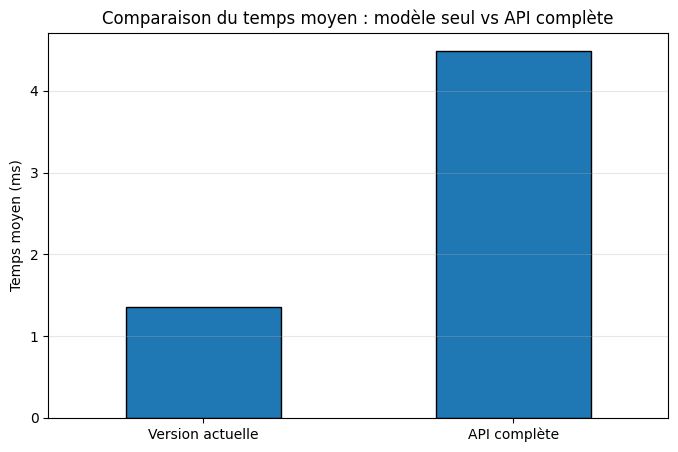

In [21]:
comparaison_temps["Temps moyen (ms)"].plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.ylabel("Temps moyen (ms)")
plt.title("Comparaison du temps moyen : modèle seul vs API complète")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

La majorité du temps observé dans les logs ne provient pas uniquement de l'inférence du modèle mais aussi du traitement applicatif autour du modèle.
Optimiser uniquement le modèle ne permettra pas nécessairement de réduire fortement le temps de réponse total de l'API. Les optimisations doivent donc aussi prendre en compte la préparation des données et le traitement de la requête.

### Profiling avec cProfile

In [22]:
def run_predictions():
    for i in range(100):
        ligne = X_test.iloc[[i]]
        model.predict_proba(ligne)

profiler = cProfile.Profile()
profiler.enable()

run_predictions()

profiler.disable()

stream = io.StringIO()
stats = pstats.Stats(profiler, stream=stream)
stats.sort_stats("cumulative")
stats.print_stats(15)

print(stream.getvalue())

         464718 function calls (451617 primitive calls) in 0.351 seconds

   Ordered by: cumulative time
   List reduced from 319 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.350    0.175 {built-in method builtins.exec}
        1    0.000    0.000    0.350    0.350 C:\Users\ocean\AppData\Local\Temp\ipykernel_28196\3346709359.py:1(<module>)
        1    0.001    0.001    0.350    0.350 C:\Users\ocean\AppData\Local\Temp\ipykernel_28196\3346709359.py:1(run_predictions)
      100    0.002    0.000    0.312    0.003 c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\lightgbm\sklearn.py:1615(predict_proba)
      100    0.003    0.000    0.309    0.003 c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\lightgbm\sklearn.py:1093(predict)
      100    0.000    0.000    0.209    0.002 c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\lightgbm\basic.py:4701(predict)
  

Le profiling montre que l'exécution de 100 prédictions prend environ 0,35 seconde au total.

La majorité du temps est passée dans les fonctions internes de LightGBM, notamment `predict_proba`, `predict` et les étapes de conversion des données depuis pandas vers le format utilisé par le modèle.

Le goulot d'étranglement principal se situe donc au niveau de l'inférence et de la préparation des données. Une piste d'optimisation pertinente consiste à limiter les conversions répétées ou à privilégier des prédictions par lot lorsque le cas d'usage le permet.

### Tests d'optimisation

#### Prédiction ligne par ligne vs prédiction en batch

In [23]:
echantillon = X_test.iloc[:100].copy()

debut = time.perf_counter()

for i in range(len(echantillon)):
    ligne = echantillon.iloc[[i]]
    model.predict_proba(ligne)

fin = time.perf_counter()

temps_ligne_par_ligne = (fin - debut) * 1000
temps_ligne_par_ligne

148.41490000071644

In [24]:
debut = time.perf_counter()

model.predict_proba(echantillon)

fin = time.perf_counter()

temps_batch = (fin - debut) * 1000
temps_batch

1.8983000009029638

In [25]:
comparaison_optimisation = pd.DataFrame({
    "Stratégie": [
        "Prédictions ligne par ligne",
        "Prédiction en batch"
    ],
    "Temps total pour 100 prédictions (ms)": [
        temps_ligne_par_ligne,
        temps_batch
    ],
    "Temps moyen par prédiction (ms)": [
        temps_ligne_par_ligne / 100,
        temps_batch / 100
    ]
})

comparaison_optimisation.round(3)

,Stratégie,Temps total pour 100 prédictions (ms),Temps moyen par prédiction (ms)
0,Prédictions ligne par ligne,148.415,1.484
1,Prédiction en batch,1.898,0.019


In [26]:
gain_batch = (
    (temps_ligne_par_ligne - temps_batch)
    / temps_ligne_par_ligne
) * 100

print(f"Gain observé avec la prédiction en batch : {gain_batch:.1f}%")

Gain observé avec la prédiction en batch : 98.7%


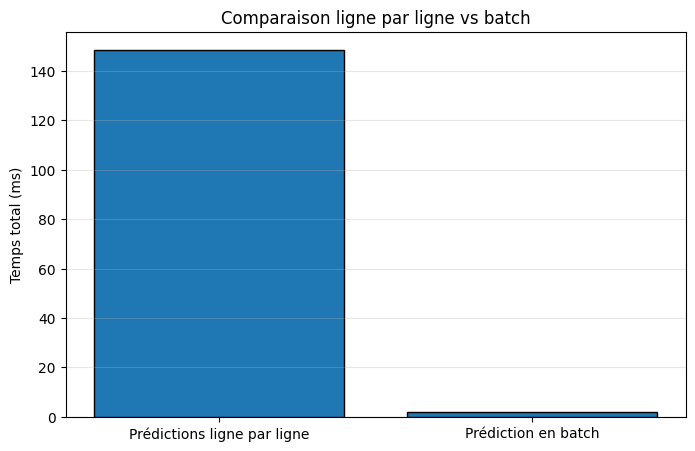

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparaison_optimisation["Stratégie"],
    comparaison_optimisation["Temps total pour 100 prédictions (ms)"],
    edgecolor="black"
)
plt.ylabel("Temps total (ms)")
plt.title("Comparaison ligne par ligne vs batch")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

La prédiction en batch est plus efficace que l'exécution de prédictions ligne par ligne car elle limite les appels répétés au modèle et réduit les conversions successives des données.

Cette optimisation est pertinente lorsque plusieurs demandes peuvent être traitées ensemble. En revanche, pour une API de scoring appelée client par client, la prédiction ligne par ligne reste cohérente avec l'usage attendu.

La stratégie retenue est donc de conserver l'inférence unitaire pour l'API actuelle, tout en identifiant le batch comme une piste d'optimisation pertinente si le volume de requêtes augmente.

#### DataFrame pandas vs tableau NumPy

In [28]:
echantillon = X_test.iloc[:100].copy()

temps_pandas = []

for i in range(len(echantillon)):
    ligne = echantillon.iloc[[i]]

    debut = time.perf_counter()
    model.predict_proba(ligne)
    fin = time.perf_counter()

    temps_pandas.append((fin - debut) * 1000)

In [29]:
echantillon_numpy = echantillon.to_numpy()

temps_numpy = []

for i in range(len(echantillon_numpy)):
    ligne = echantillon_numpy[i].reshape(1, -1)

    debut = time.perf_counter()
    model.predict_proba(ligne)
    fin = time.perf_counter()

    temps_numpy.append((fin - debut) * 1000)

c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature nam

In [30]:
comparaison_format = pd.DataFrame({
    "Format d'entrée": ["DataFrame pandas", "Tableau NumPy"],
    "Temps moyen (ms)": [
        np.mean(temps_pandas),
        np.mean(temps_numpy)
    ],
    "P95 (ms)": [
        np.percentile(temps_pandas, 95),
        np.percentile(temps_numpy, 95)
    ],
    "Temps max (ms)": [
        np.max(temps_pandas),
        np.max(temps_numpy)
    ]
})

comparaison_format.round(3)

,Format d'entrée,Temps moyen (ms),P95 (ms),Temps max (ms)
0,DataFrame pandas,1.374,1.649,2.190
1,Tableau NumPy,1.037,1.060,10.418


In [31]:
gain_numpy = (
    (np.mean(temps_pandas) - np.mean(temps_numpy))
    / np.mean(temps_pandas)
) * 100

print(f"Gain moyen avec NumPy : {gain_numpy:.1f}%")

Gain moyen avec NumPy : 24.5%


La conversion des données en tableau NumPy permet de réduire le temps moyen d'inférence d'environ 24,5 % par rapport à l'utilisation d'un DataFrame pandas. Les indicateurs les plus représentatifs (temps moyen et P95) montrent une amélioration globale des performances.

Cette optimisation sera donc retenue pour la version finale de l'API.

In [32]:
# Mesure de l'API après optimisation
logs_apres = pd.read_json(LOG_PATH, lines=True)

logs_apres["timestamp"] = pd.to_datetime(logs_apres["timestamp"])

logs_apres.tail()

,timestamp,score,prediction,inference_time_ms,features
196,2026-07-01 10:54:18.285006+00:00,0.207374,0,7.97,"{'CNT_CHILDREN': 1.0, 'AMT_INCOME_TOTAL': 9000..."
197,2026-07-01 10:54:19.008982+00:00,0.346263,0,4.02,"{'CNT_CHILDREN': 0.0, 'AMT_INCOME_TOTAL': 1800..."
198,2026-07-01 10:54:19.754978+00:00,0.065079,0,3.29,"{'CNT_CHILDREN': 1.0, 'AMT_INCOME_TOTAL': 1350..."
199,2026-07-01 10:54:20.482432+00:00,0.257710,0,7.89,"{'CNT_CHILDREN': 0.0, 'AMT_INCOME_TOTAL': 9000..."
200,2026-07-01 10:54:21.191767+00:00,0.157326,0,3.68,"{'CNT_CHILDREN': 0.0, 'AMT_INCOME_TOTAL': 1575..."


In [33]:
logs_optimises = logs_apres.tail(100).copy()

benchmark_api_optimisee = {
    "Temps moyen (ms)": logs_optimises["inference_time_ms"].mean(),
    "Temps médian (ms)": logs_optimises["inference_time_ms"].median(),
    "P95 (ms)": logs_optimises["inference_time_ms"].quantile(0.95),
    "Temps maximum (ms)": logs_optimises["inference_time_ms"].max(),
    "Temps minimum (ms)": logs_optimises["inference_time_ms"].min()
}

benchmark_api_optimisee = pd.DataFrame(
    benchmark_api_optimisee,
    index=["API optimisée"]
)

benchmark_api_optimisee.round(3)

,Temps moyen (ms),Temps médian (ms),P95 (ms),Temps maximum (ms),Temps minimum (ms)
API optimisée,4.274,3.415,7.951,10.05,3.09


In [34]:
comparaison_api = pd.concat([
    benchmark_api,
    benchmark_api_optimisee
])

comparaison_api.round(3)

,Temps moyen (ms),Temps médian (ms),P95 (ms),Temps maximum (ms),Temps minimum (ms)
API complète,4.486,3.930,7.200,8.10,3.25
API optimisée,4.274,3.415,7.951,10.05,3.09


In [35]:
gain_api = (
    (benchmark_api.loc["API complète", "Temps moyen (ms)"]
     - benchmark_api_optimisee.loc["API optimisée", "Temps moyen (ms)"])
    / benchmark_api.loc["API complète", "Temps moyen (ms)"]
) * 100

print(f"Gain moyen observé côté API après optimisation : {gain_api:.1f}%")

Gain moyen observé côté API après optimisation : 4.7%


### Synthèse des optimisations réalisées

L'analyse des performances a été réalisée sur le modèle déployé ainsi que sur l'API afin de distinguer le temps d'inférence du temps de réponse global observé en production.

Le benchmark montre que le modèle LightGBM est déjà rapide (environ 1 ms par prédiction), tandis que le temps moyen mesuré côté API est d'environ 4 ms. Le modèle ne représente ainsi qu'environ 30 % du temps total d'une requête, le reste étant lié au traitement de la requête, à la préparation des données et à l'écriture des logs.

Le profiling réalisé avec cProfile a permis d'identifier les principaux goulots d'étranglement. Les fonctions les plus coûteuses correspondent à l'appel de `predict_proba` ainsi qu'aux étapes de préparation et de conversion des données avant l'inférence (`_data_from_pandas`, `_pandas_to_numpy` et `_check_for_bad_pandas_dtypes`).

À partir de cette analyse, deux stratégies d'optimisation ont été testées. La première consiste à convertir les données d'entrée au format NumPy avant l'appel au modèle. Cette approche réduit le temps moyen d'inférence d'environ 24,5 % et, une fois intégrée à l'API, permet un gain d'environ 4,7 % sur le temps moyen de réponse. La seconde stratégie consistait à réaliser les prédictions par lot (batch), mais cette approche n'a pas été retenue car l'API est destinée à traiter une demande de scoring à la fois.

La configuration finale conserve donc le modèle LightGBM, déployé au sein d'une API FastAPI exécutée avec Uvicorn, avec une conversion des données au format NumPy avant l'appel à `predict_proba`. Cette solution améliore les performances sans modifier le modèle entraîné ni son comportement, tout en restant compatible avec le pipeline CI/CD mis en place pour le déploiement.